In [1]:
!pip install scikit-learn numpy matplotlib pandas


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

mnist = fetch_openml('mnist_784', as_frame=False)
mnist_X = mnist.data.astype('float32')
mnist_y = mnist.target.astype('int64')

In [2]:
# Keep only samples labeled 0 or 7
# mask_07 = (mnist_y == 0) | (mnist_y == 7)
# mnist_X = mnist_X[mask_07]
# mnist_y = mnist_y[mask_07]

# Keep only samples labeled 0, 1, 2, 3, 4, or 5
mask_0_to_5 = (mnist_y >= 0) & (mnist_y <= 5)
mnist_X = mnist_X[mask_0_to_5]
mnist_y = mnist_y[mask_0_to_5]

In [3]:
# Convert grayscale MNIST vectors to binary vectors
# mnist_X = (mnist_X > 123).astype(np.uint8) # uncomment if using ART1

# Convert grayscale MNIST vectors to normalized vectors (range 0..1)
mnist_X = mnist_X.astype(np.float32) / 255.0 # uncomment if using Fuzzy ART

In [4]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    mnist_X,
    mnist_y,
    test_size=0.2,
    random_state=42,
    stratify=mnist_y,
 )

print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Train samples: 33638
Test samples: 8410


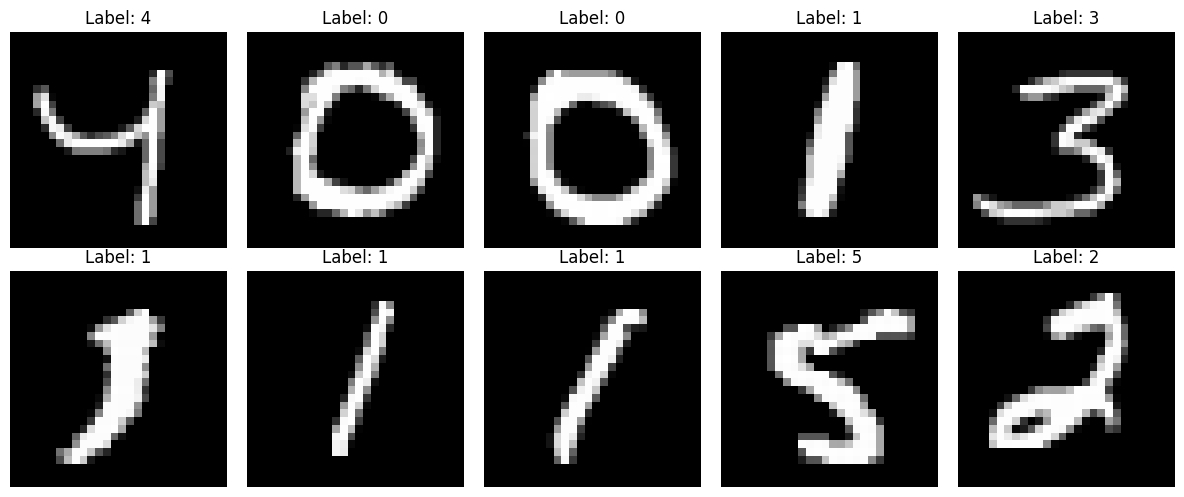

In [5]:
# Visualize some samples
n = 10
idx = np.random.choice(len(mnist_X), n, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, i in zip(axes.ravel(), idx):
    img = mnist_X[i].reshape(28, 28)   # MNIST is flattened (784,) -> (28, 28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {mnist_y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
class Art1:

    def __init__(self, num_features: int, max_clusters: int = 20, vigilance: float = 0.5):
        if not (0 < vigilance <= 1):
            raise ValueError("Vigilance must be in the range (0, 1].")

        self.vigilance = vigilance # ρ ∈ [0, 1]
        self.num_clusters = 0
        self.max_clusters = max_clusters
        self.num_features = num_features
        # β is a small positive constant (often β < 1)
        self.beta = 0.5
        # Bottom-up weights: b = [b₁ₖ, b₂ₖ, …, bₙₖ] (from F1 to F2 layer)
        self.w_bu = np.full((self.max_clusters, self.num_features), self.beta / (self.beta + self.num_features))
        # Top-down weights (prototype): t = [t₁ₖ, t₂ₖ, …, tₙₖ] (from F2 to F1 layer)
        self.w_td = np.ones((self.max_clusters, self.num_features))

    def _f2_activation(self, X: np.ndarray) -> np.ndarray:
        activations = np.zeros(self.num_clusters)
        # zₖ = ∑ᵢ xᵢ · bᵢₖ
        for j in range(self.num_clusters):
            activations[j] = np.dot(X, self.w_bu[j])
        
        return activations

    def _vigilance_test(self, X: np.ndarray, best_cluster: int) -> bool:
        # |x ∩ tₖ|/|x| = ∑ᵢ(xᵢ · tᵢₖ)/∑ᵢxᵢ
        x_sum = np.sum(X)
        if x_sum == 0:
            return False
        match_ratio = np.dot(X, self.w_td[best_cluster]) / x_sum
        # |x ∩ tₖ|/|x| ≥ ρ
        return match_ratio >= self.vigilance

    def _update_weights(self, X: np.ndarray, cluster_idx: int):
        # tᵢₖ(new) = xᵢ · tᵢₖ(old)
        new_t = X * self.w_td[cluster_idx]
        self.w_td[cluster_idx] = new_t
        # bᵢₖ(new) = β/(β + |tₖ(new)|) · tᵢₖ(new)
        self.w_bu[cluster_idx] = self.beta / (self.beta + np.sum(new_t)) * new_t

    def train(self, X: np.ndarray) -> int:
        X = np.asarray(X, dtype=float)
        if X.shape != (self.num_features,):
            raise ValueError(f"Expected input of shape ({self.num_features},), got {X.shape}.")
        if not np.all((X == 0) | (X == 1)):
            raise ValueError("ART1 requires binary inputs (values must be 0 or 1).")

        inhibited = set()

        while True:
            # 1. Comparison Phase (F1 → F2 propagation)
            if self.num_clusters == 0:
                best_cluster = None
            else:
                # Calculate the activation of each F2 neuron k:
                f2_activations = self._f2_activation(X)
                for j in inhibited:
                    f2_activations[j] = -np.inf
                # Select the F2 neuron K with the highest activation:
                # K = argmax(zₖ)
                best_cluster = int(np.argmax(f2_activations))

            # 2. Matching Phase (Vigilance Test)
            if best_cluster is not None and best_cluster not in inhibited:
                if self._vigilance_test(X, best_cluster):
                    self._update_weights(X, best_cluster)
                    return best_cluster
                else:
                    inhibited.add(best_cluster)

            # 3. Learning Phase
            if self.num_clusters >= self.max_clusters:
                raise RuntimeError(
                    f"Maximum number of clusters ({self.max_clusters}) reached. "
                    "Increase max_clusters or lower vigilance."
                )
            new_idx = self.num_clusters
            self.num_clusters += 1
            self._update_weights(X, new_idx)
            return new_idx

    def predict(self, X: np.ndarray) -> int:
        X = np.asarray(X, dtype=float)
        if self.num_clusters == 0:
            return -1

        activations = self._f2_activation(X)
        sorted_clusters = np.argsort(activations[:self.num_clusters])[::-1]

        for j in sorted_clusters:
            if self._vigilance_test(X, j):
                return int(j)
        return -1

In [7]:
class FuzzyART:

    def __init__(self, num_features: int, max_clusters: int = 20, vigilance: float = 0.5, learning_rate: float = 1.0, alpha: float = 0.001, complement: bool = True):
        if not (0 < vigilance <= 1):
            raise ValueError("Vigilance must be in the range (0, 1].")

        self.vigilance = vigilance # ρ ∈ [0, 1]
        self.num_clusters = 0
        self.max_clusters = max_clusters
        self.num_features = num_features * 2 if complement else num_features
        # β is a small positive constant (often β < 1)
        self.beta = learning_rate
        # α is a small positive constant used in the choice function.
        self.alpha = alpha
        # for each feature xi​, its complement (1−xi)​ is also included in the input vector
        self.complement = complement
        # Bottom-up weights: b = [b₁ₖ, b₂ₖ, …, bₙₖ] (from F1 to F2 layer)
        # self.w_bu = np.full((self.max_clusters, self.num_features), self.beta / (self.beta + self.num_features))
        # Top-down weights (prototype): t = [t₁ₖ, t₂ₖ, …, tₙₖ] (from F2 to F1 layer)
        self.weights = np.ones((self.max_clusters, self.num_features))

    def _complement_code(self, X: np.ndarray) -> np.ndarray:
        return np.concatenate([X, 1 - X])

    def _fuzzy_and(self, X: np.ndarray, W: np.ndarray) -> np.ndarray:
        return np.minimum(X, W)

    def _f2_activation(self, X: np.ndarray) -> np.ndarray:
        activations = np.zeros(self.num_clusters)
        # Tj = ‖x ∧ Wj‖ / α + ‖Wj‖
        for j in range(self.num_clusters):
            activations[j] = np.sum(self._fuzzy_and(X, self.weights[j])) / (self.alpha + np.sum(self.weights[j]))
            # print(f"Cluster {j}: activation={activations[j]:.4f}")
        return activations

    def _vigilance_test(self, X: np.ndarray, best_cluster: int) -> bool:
        # ‖x ∧ Wj‖ / ‖x‖ ≥ ρ
        fuzzy_and_norm = np.sum(self._fuzzy_and(X, self.weights[best_cluster]))
        if fuzzy_and_norm == 0:
            return False
        match_ratio = fuzzy_and_norm / np.sum(X)
        # print(f"Cluster {best_cluster}: match_ratio={match_ratio:.4f}, vigilance={self.vigilance}")
        return match_ratio >= self.vigilance

    def _update_weights(self, X: np.ndarray, cluster_idx: int):
        # wJ (new) = β(x ∧ wJ (old)) + (1 − β)wJ (old)
        new_wj = self.beta * self._fuzzy_and(X, self.weights[cluster_idx]) + (1 - self.beta) * self.weights[cluster_idx]
        self.weights[cluster_idx] = new_wj

    def train(self, X: np.ndarray) -> int:
        X = np.asarray(X, dtype=float)
        X = self._complement_code(X) if self.complement else X

        if X.shape != (self.num_features,):
            raise ValueError(f"Expected input of shape ({self.num_features},), got {X.shape}.")

        inhibited = set()

        while True:
            # 1. Comparison Phase (F1 → F2 propagation)
            if self.num_clusters == 0:
                best_cluster = None
            else:
                # Calculate the activation of each F2 neuron k:
                f2_activations = self._f2_activation(X)
                for j in inhibited:
                    f2_activations[j] = -np.inf
                # Select the F2 neuron K with the highest activation:
                # K = argmax(zₖ)
                best_cluster = int(np.argmax(f2_activations))

            # 2. Matching Phase (Vigilance Test)
            if best_cluster is not None and best_cluster not in inhibited:
                if self._vigilance_test(X, best_cluster):
                    self._update_weights(X, best_cluster)
                    return best_cluster
                else:
                    inhibited.add(best_cluster)

            # 3. Learning Phase
            if self.num_clusters >= self.max_clusters:
                raise RuntimeError(
                    f"Maximum number of clusters ({self.max_clusters}) reached."
                    "Increase max_clusters or lower vigilance."
                )
            new_idx = self.num_clusters
            self.num_clusters += 1
            self.weights[new_idx] = X.copy()
            return new_idx

    def predict(self, X: np.ndarray) -> int:
        X = np.asarray(X, dtype=float)
        X = self._complement_code(X) if self.complement else X
        if self.num_clusters == 0:
            return -1

        activations = self._f2_activation(X)
        sorted_clusters = np.argsort(activations[:self.num_clusters])[::-1]

        for j in sorted_clusters:
            if self._vigilance_test(X, j):
                return int(j)
        return sorted_clusters[0]

    def get_weights(self) -> np.ndarray:
        return self.weights[:self.num_clusters]

In [8]:
# Divide training data into two halves for incremental learning
X_train_1st_half = X_train[:len(X_train) // 2]
X_train_2nd_half = X_train[len(X_train) // 2:]

y_train_1st_half = y_train[:len(y_train) // 2]
y_train_2nd_half = y_train[len(y_train) // 2:]

In [11]:
# Train ART1 with binary MNIST training split
# net = Art1(
#     num_features=X_train.shape[1],
#     max_clusters=100000,
#     vigilance=0.3,
#  )

net = FuzzyART(
    num_features=X_train_1st_half.shape[1],
    max_clusters=100000,
    vigilance=0.5,
    learning_rate=0.5,
    alpha=0.01,
    complement=True,
)

cluster_assignments = np.full(len(X_train_1st_half), -1, dtype=np.int32)
for i, x in enumerate(X_train_1st_half):
    try:
        cluster_assignments[i] = net.train(x)
    except RuntimeError:
        cluster_assignments = cluster_assignments[:i]
        print(f"Stopped at sample {i}")
        break

print(f"Active clusters: {net.num_clusters}")
print(f"Trained samples: {len(cluster_assignments)}")

# with open("weights.txt", "w") as f:
#     for idx in cluster_assignments:
#         f.write(f"{idx}\n")

# with open("cluster_weights.txt", "w") as f:
#     for weight in net.get_weights():
#         f.write(f"{', '.join(map(str, weight))}\n")

Active clusters: 16720
Trained samples: 16819


Total clusters found: 16720


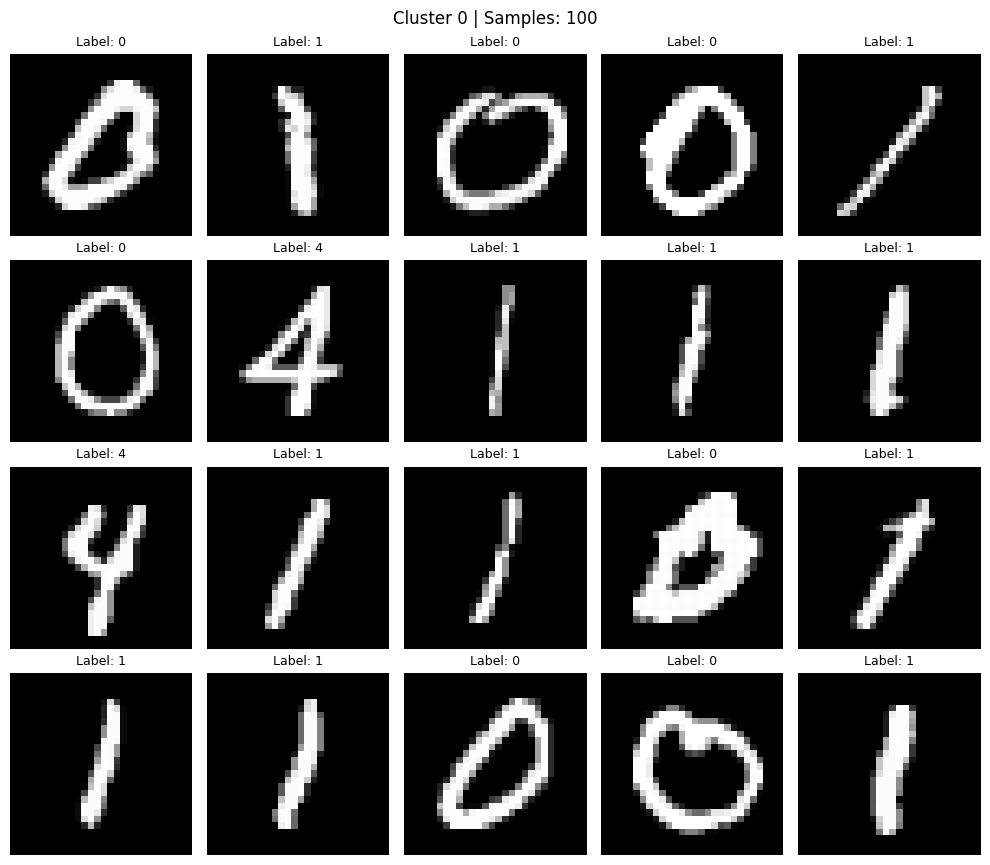

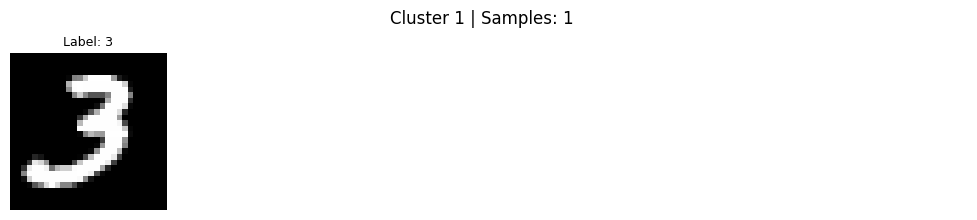

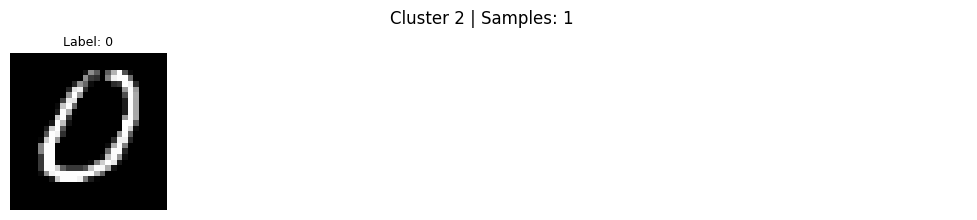

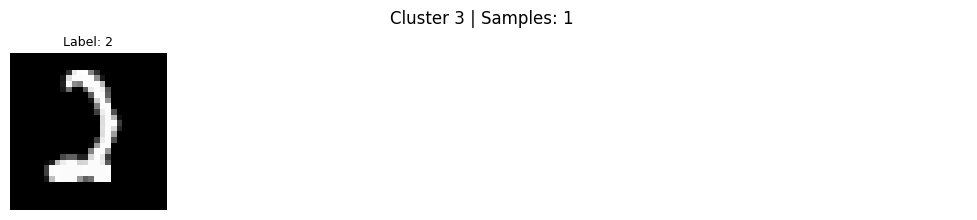

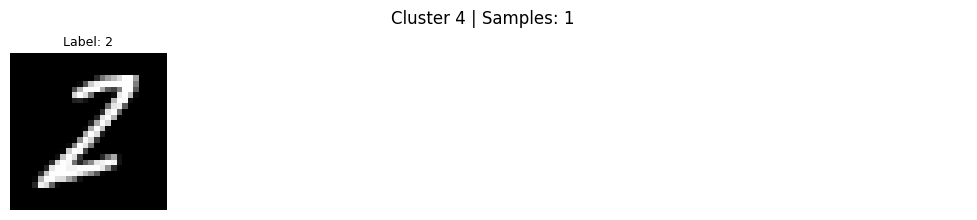

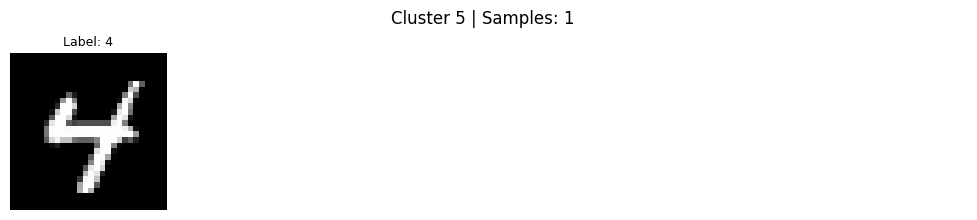

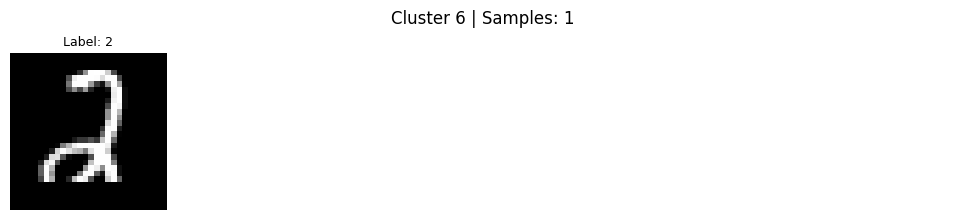

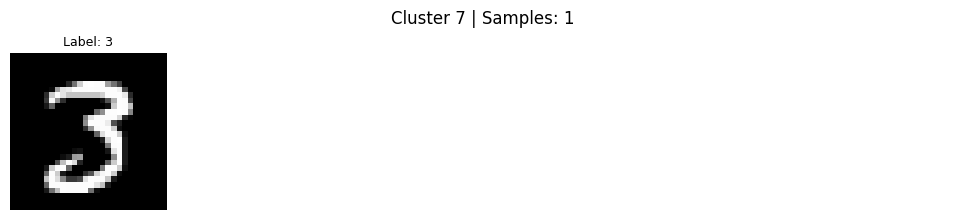

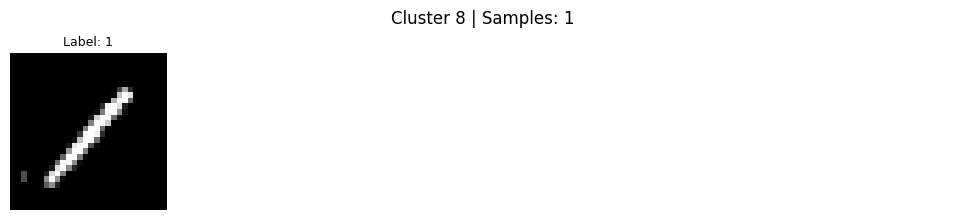

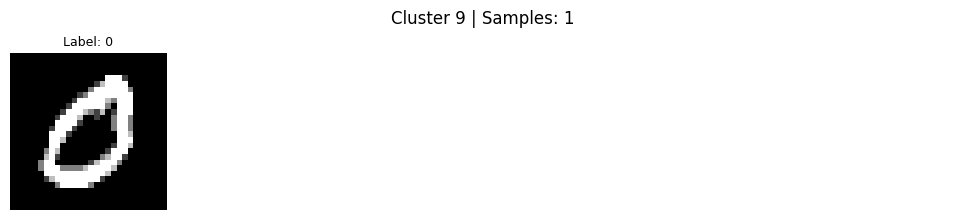

In [12]:
# Show image samples for each cluster
trained_n = len(cluster_assignments)
X_trained = X_train_1st_half[:trained_n]
y_trained = y_train_1st_half[:trained_n]

samples_per_cluster = 20
cluster_ids = np.unique(cluster_assignments)

print(f"Total clusters found: {len(cluster_ids)}")

for cluster_id in cluster_ids[:10]:
    idx = np.where(cluster_assignments == cluster_id)[0]
    if len(idx) == 0:
        continue

    # Pick up to N samples from this cluster (randomized for variety)
    n_show = min(samples_per_cluster, len(idx))
    show_idx = np.random.choice(idx, size=n_show, replace=False)

    cols = 5
    rows = int(np.ceil(n_show / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.2))
    axes = np.array(axes).reshape(-1)

    for ax, sample_i in zip(axes, show_idx):
        ax.imshow(X_trained[sample_i].reshape(28, 28), cmap="gray")
        ax.set_title(f"Label: {y_trained[sample_i]}", fontsize=9)
        ax.axis("off")

    for ax in axes[n_show:]:
        ax.axis("off")

    fig.suptitle(f"Cluster {cluster_id} | Samples: {len(idx)}", fontsize=12)
    plt.tight_layout()
    plt.show()

In [13]:
from collections import Counter

y_trained = y_train[:trained_n]

purities = []
cluster_label_map = {}

print("\nCluster purity analysis:")
for cid in cluster_ids:
    idx = np.where(cluster_assignments == cid)[0]
    label_counts = Counter(y_trained[idx])
    dominant = label_counts.most_common(1)[0]
    cluster_label_map[cid] = dominant[0]
    purity = dominant[1] / len(idx)
    purities.append(purity)
    print(f"Cluster {cid:2d}: {len(idx):5d} samples | dominant digit={dominant[0]} | purity={purity:.1%}")

# ponder overall accuracy by cluster size
weights = np.array([len(np.where(cluster_assignments == cid)[0]) for cid in cluster_ids])
accuracy = np.average(purities, weights=weights)
print(f"Overall accuracy: {accuracy:.1%}")


Cluster purity analysis:
Cluster  0:   100 samples | dominant digit=1 | purity=55.0%
Cluster  1:     1 samples | dominant digit=3 | purity=100.0%
Cluster  2:     1 samples | dominant digit=0 | purity=100.0%
Cluster  3:     1 samples | dominant digit=2 | purity=100.0%
Cluster  4:     1 samples | dominant digit=2 | purity=100.0%
Cluster  5:     1 samples | dominant digit=4 | purity=100.0%
Cluster  6:     1 samples | dominant digit=2 | purity=100.0%
Cluster  7:     1 samples | dominant digit=3 | purity=100.0%
Cluster  8:     1 samples | dominant digit=1 | purity=100.0%
Cluster  9:     1 samples | dominant digit=0 | purity=100.0%
Cluster 10:     1 samples | dominant digit=5 | purity=100.0%
Cluster 11:     1 samples | dominant digit=3 | purity=100.0%
Cluster 12:     1 samples | dominant digit=4 | purity=100.0%
Cluster 13:     1 samples | dominant digit=2 | purity=100.0%
Cluster 14:     1 samples | dominant digit=2 | purity=100.0%
Cluster 15:     1 samples | dominant digit=2 | purity=100.0%

Mismatch at sample 42: expected 1, predicted 4


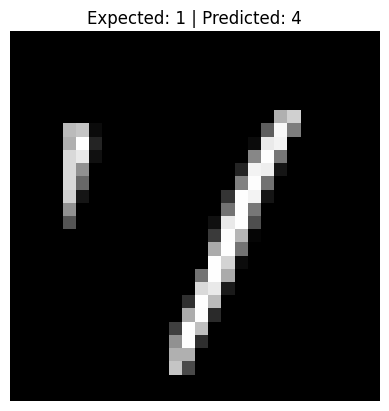

Mismatch at sample 51: expected 2, predicted 0


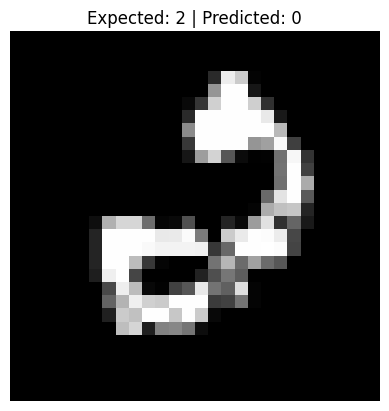

Mismatch at sample 98: expected 3, predicted 2


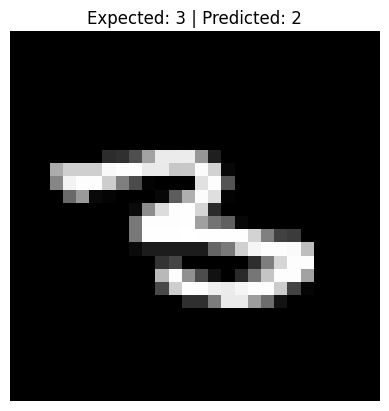

Mismatch at sample 181: expected 5, predicted 3


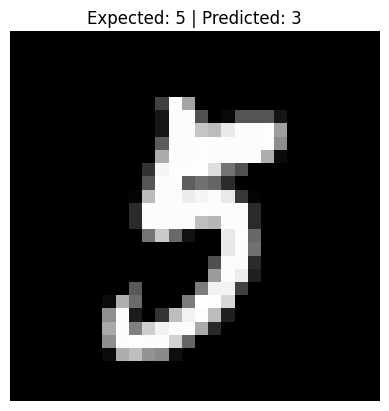

Mismatch at sample 334: expected 4, predicted 0


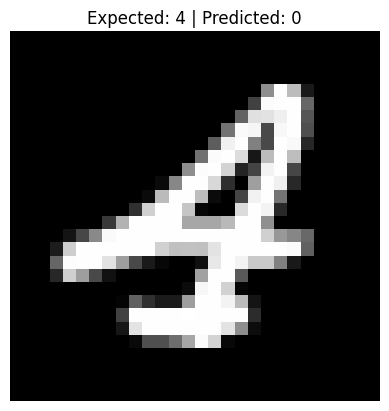

Mismatch at sample 384: expected 5, predicted 3


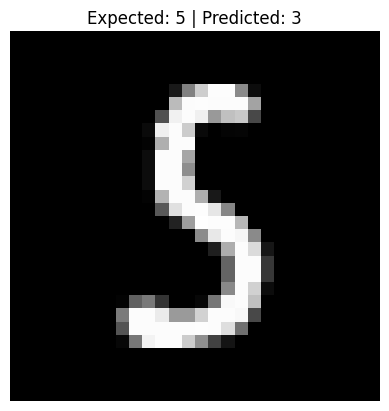

Mismatch at sample 391: expected 2, predicted 1


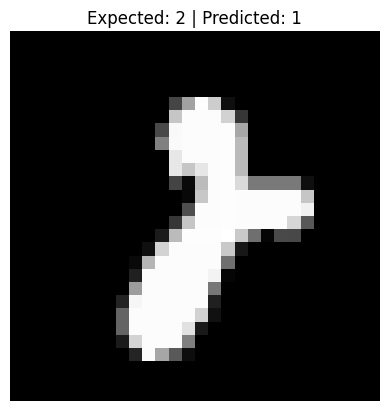

Mismatch at sample 399: expected 4, predicted 1


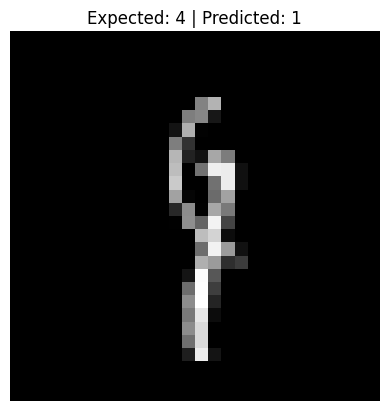

Mismatch at sample 500: expected 2, predicted 3


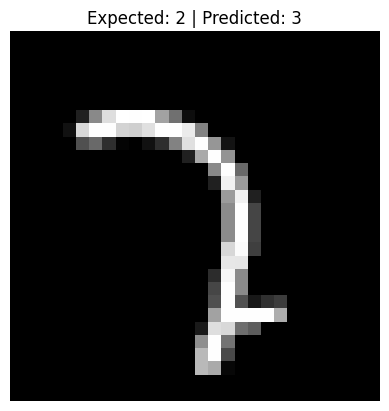

Mismatch at sample 523: expected 2, predicted 1


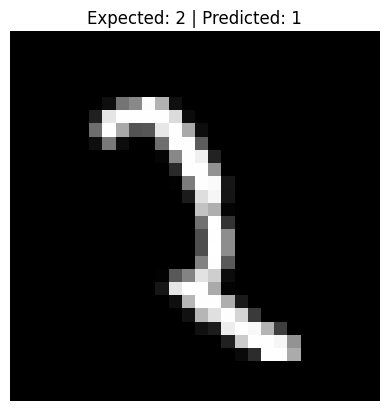

Correct predictions: 8226 out of 8410
Accuracy: 97.81%


In [14]:
def predict_digit(net, cluster_label_map, X):
    cluster_id = net.predict(X)
    if cluster_id == -1:
        return None  # no matching cluster found
    return cluster_label_map[cluster_id]


def display_image_and_prediction(image, expected, predicted):
    plt.imshow(image.reshape(28, 28), cmap="gray")
    plt.title(f"Expected: {expected} | Predicted: {predicted}")
    plt.axis("off")
    plt.show()


accuracy_count = 0
number_to_test = min(10000, len(X_test))
mismatch_count = 0

for i, X in enumerate(X_test[:number_to_test]):
    predicted_digit = predict_digit(net, cluster_label_map, X)
    actual_digit = y_test[i]

    if predicted_digit == actual_digit:
        accuracy_count += 1

    if predicted_digit != actual_digit:
        if mismatch_count >= 10:
            continue
        mismatch_count += 1
        print(f"Mismatch at sample {i}: expected {actual_digit}, predicted {predicted_digit}")
        display_image_and_prediction(X, actual_digit, predicted_digit)

print(f"Correct predictions: {accuracy_count} out of {number_to_test}")
print(f"Accuracy: {accuracy_count / number_to_test * 100:.2f}%")

Accuracy and mean samples/cluster per vigilance:
v=0.50 | clusters=16720 | mean_samples=1.01 | accuracy=97.81%
v=0.60 | clusters=16642 | mean_samples=1.01 | accuracy=97.73%
v=0.70 | clusters=15430 | mean_samples=1.09 | accuracy=97.28%
v=0.78 | clusters=15741 | mean_samples=1.07 | accuracy=97.42%
v=0.85 | clusters=15117 | mean_samples=1.11 | accuracy=97.60%


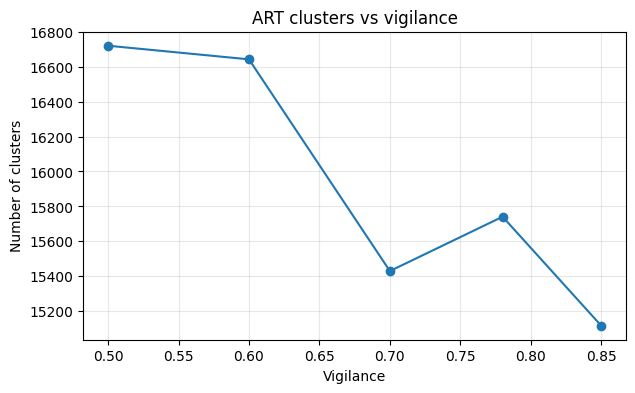

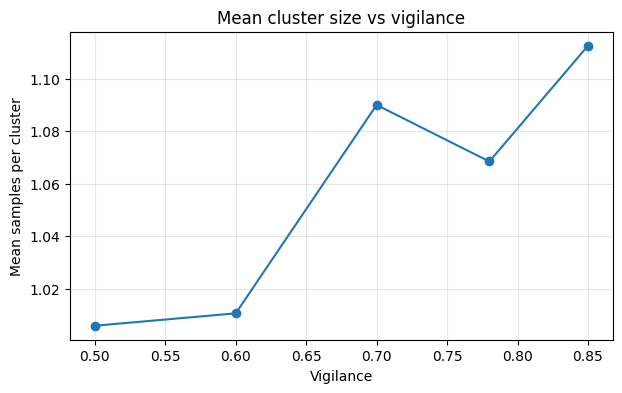

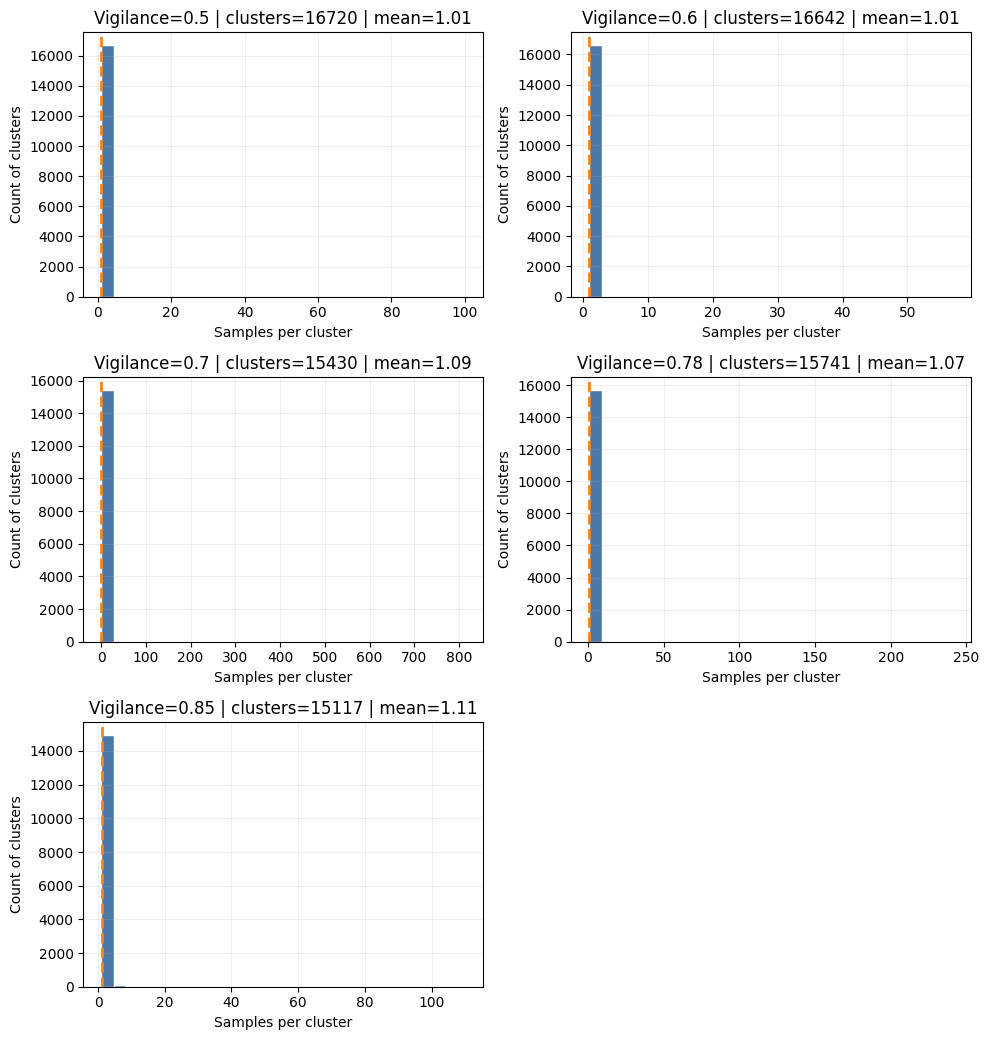

In [ ]:
# Evaluate cluster counts vs vigilance and show cluster size histograms
vigilance_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
max_clusters = 100000
sample_limit = min(100000, len(X_train_1st_half))
results = {}
weights = []

for v in vigilance_values:
    net_v = FuzzyART(
        num_features=X_train_1st_half.shape[1],
        max_clusters=max_clusters,
        vigilance=v,
        learning_rate=0.5,
        alpha=0.01,
        complement=True,
    )
    weights.append(net_v.get_weights())
    assignments = []
    for i, x in enumerate(X_train_1st_half[:sample_limit]):
        try:
            assignments.append(net_v.train(x))
        except RuntimeError:
            break
    assignments = np.array(assignments, dtype=np.int32)
    cluster_ids = np.unique(assignments)
    counts = np.array([np.sum(assignments == cid) for cid in cluster_ids])
    mean_cluster_size = float(np.mean(counts)) if len(counts) else 0.0

    # Build cluster-to-label mapping from training subset
    y_train_subset = y_train_1st_half[:len(assignments)]
    cluster_label_map = {}
    for cid in cluster_ids:
        idx = np.where(assignments == cid)[0]
        labels, label_counts = np.unique(y_train_subset[idx], return_counts=True)
        cluster_label_map[cid] = labels[np.argmax(label_counts)]

    # Evaluate accuracy on test set
    correct = 0
    total = len(X_test)
    for i, x in enumerate(X_test):
        cid = net_v.predict(x)
        if cid == -1:
            continue
        if cluster_label_map.get(cid, None) == y_test[i]:
            correct += 1
    accuracy = correct / total

    results[v] = {
        "num_clusters": net_v.num_clusters,
        "counts": counts,
        "mean_cluster_size": mean_cluster_size,
        "accuracy": accuracy,
    }

print("Accuracy and mean samples/cluster per vigilance:")
for v in vigilance_values:
    print(
        f"v={v:.2f} | clusters={results[v]['num_clusters']} | "
        f"mean_samples={results[v]['mean_cluster_size']:.2f} | "
        f"accuracy={results[v]['accuracy'] * 100:.2f}%"
    )

# Line plot: vigilance vs number of clusters
plt.figure(figsize=(7, 4))
plt.plot(list(results.keys()), [results[v]["num_clusters"] for v in results], marker="o")
plt.xlabel("Vigilance")
plt.ylabel("Number of clusters")
plt.title("ART clusters vs vigilance")
plt.grid(True, alpha=0.3)
plt.show()

# Line plot: vigilance vs mean samples per cluster
plt.figure(figsize=(7, 4))
plt.plot(list(results.keys()), [results[v]["mean_cluster_size"] for v in results], marker="o")
plt.xlabel("Vigilance")
plt.ylabel("Mean samples per cluster")
plt.title("Mean cluster size vs vigilance")
plt.grid(True, alpha=0.3)
plt.show()

# Print exact cluster-size counts per vigilance
for v in vigilance_values:
    counts = results[v]["counts"].astype(int)
    size_counts = np.bincount(counts)
    size_counts = size_counts[1:]  # drop size 0
    sizes = np.arange(1, len(size_counts) + 1)
    print(f"\nVigilance={v:.2f} | cluster-size counts:")
    for size, count in zip(sizes, size_counts):
        if count > 0:
            print(f"  size={size:3d} -> clusters={count}")

# Bar charts: exact count of clusters per sample size
cols = 2
rows = int(np.ceil(len(vigilance_values) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, v in zip(axes, vigilance_values):
    counts = results[v]["counts"].astype(int)
    size_counts = np.bincount(counts)
    size_counts = size_counts[1:]  # drop size 0
    sizes = np.arange(1, len(size_counts) + 1)
    ax.bar(sizes, size_counts, width=0.9, color="#4C78A8", edgecolor="white")
    ax.set_title(
        f"Vigilance={v} | clusters={results[v]['num_clusters']} | mean={results[v]['mean_cluster_size']:.2f}"
    )
    ax.set_xlabel("Samples per cluster")
    ax.set_ylabel("Count of clusters")
    ax.grid(True, axis="y", alpha=0.2)
    if len(sizes) <= 25:
        ax.set_xticks(sizes)

for ax in axes[len(vigilance_values):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Results

- ### 0's & 7's
    - *vigilance parameter = 0.3*
        
            Trained samples: 11356
            Active clusters: 8207
            Clusters purity (%) = 99.9%

            Correct predictions: 2834 out of 2840
            Accuracy: 99.79%

    - *vigilance parameter = 0.5*
        
            Trained samples: 11356
            Active clusters: 9249
            Clusters purity (%) = 100%

            Correct predictions: 2830 out of 2840
            Accuracy: 99.65%

    - *vigilance parameter = 0.8*

            Trained samples: 11356
            Active clusters: 10827
            Clusters purity (%) = 100%

            Correct predictions: 2823 out of 2840
            Accuracy: 99.40%

- ### All numbers dataset
    - *vigilance parameter = 0.3*
        
            Trained samples: 56000
            Active clusters: 42866
            Clusters purity (%) = 98.3%

            Correct predictions: 8590 out of 10000
            Accuracy: 85.90%




